# Mean Curvature Flow of a Planar Curve

For a planar curve $\gamma(s,t)$ parametrized by arc length, mean-curvature flow obeys
$$
\partial_t \gamma = \kappa\,n,
$$
where $\kappa$ is scalar curvature and $n$ is the inward normal.
Using a periodic polygonal discretization, we approximate
$$
\kappa n \approx \frac{\gamma_{i+1}-2\gamma_i+\gamma_{i-1}}{\Delta s^2}
$$
and evolve for a longer horizon from a less regular initial curve.


## Discretization and evolution


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

OUT = Path("python/mean-curvature-flow"); OUT.mkdir(parents=True, exist_ok=True)
n = 420
th = np.linspace(0, 2*np.pi, n, endpoint=False)
r = 1.0 + 0.22*np.cos(3*th+0.2) + 0.11*np.cos(8*th+1.0) + 0.05*np.sign(np.sin(5*th))
x = r*np.cos(th); y = r*np.sin(th)
P = np.c_[x, y]
dt = 2.5e-4
n_steps = 4800
snap_idx = [0, 900, 1900, 3200, 4799]
snaps = []
for k in range(n_steps):
    Pp = np.roll(P, -1, axis=0)
    Pm = np.roll(P, 1, axis=0)
    d1 = Pp - Pm
    ds = np.sqrt((d1**2).sum(axis=1)) + 1e-12
    ds2 = (0.5*ds)**2
    curv_vec = (Pp - 2*P + Pm) / ds2[:, None]
    P = P + dt * curv_vec
    P -= P.mean(axis=0, keepdims=True)
    if k in snap_idx:
        snaps.append(P.copy())


/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_67198/3405515861.py:23: RuntimeWarning: overflow encountered in square
  ds = np.sqrt((d1**2).sum(axis=1)) + 1e-12
/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_67198/3405515861.py:25: RuntimeWarning: overflow encountered in divide
  curv_vec = (Pp - 2*P + Pm) / ds2[:, None]
/Users/gpeyre/miniconda3/envs/py314/lib/python3.14/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


## Long-time geometric regularization


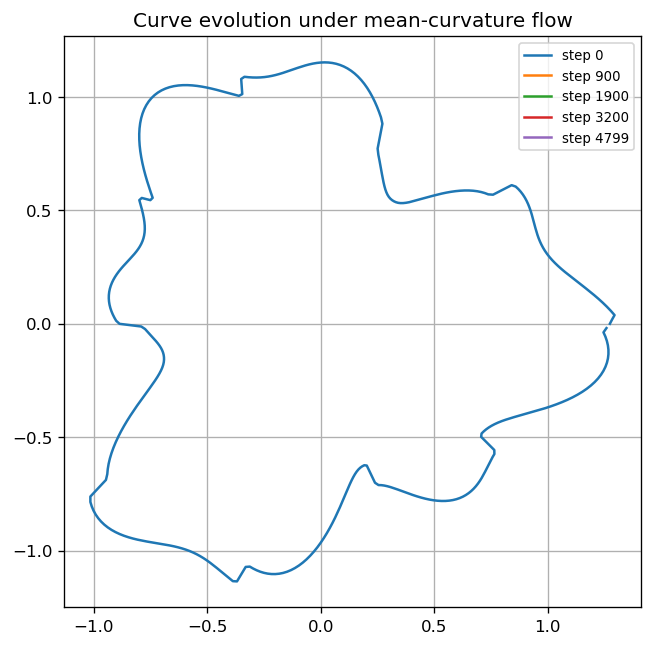

In [2]:
fig, ax = plt.subplots(figsize=(6.2, 6.2))
for S, k in zip(snaps, snap_idx):
    ax.plot(S[:,0], S[:,1], lw=1.5, label=f"step {k}")
ax.set_aspect("equal")
ax.set_title("Curve evolution under mean-curvature flow")
ax.legend(loc="upper right", fontsize=8)
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- S. Osher, J. A. Sethian, "Fronts Propagating with Curvature-Dependent Speed", JCP, 1988.
- L. C. Evans, J. Spruck, "Motion of Level Sets by Mean Curvature I", JDE, 1991.
- G. Sapiro, *Geometric Partial Differential Equations and Image Analysis*, Cambridge Univ. Press, 2001.
